In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte


In [3]:
import pandas as pd

train_path = "/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv"
test_path = "/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv"

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)
print("\nDataset loaded successfully!")

Training data shape: (60000, 785)
Testing data shape: (10000, 785)

Dataset loaded successfully!


In [4]:
print("Training Dataset:")
display(train_data.head())

print("\nColumn names:")
print(train_data.columns[:10].tolist())

print("\nMissing values:", train_data.isnull().sum().sum())

Training Dataset:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Column names:
['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7', 'pixel8', 'pixel9']

Missing values: 0


In [5]:
print("Number of classes:", train_data["label"].nunique())
print("Classes:", sorted(train_data["label"].unique()))

print("\nClass distribution:")
print(train_data["label"].value_counts().sort_index())

Number of classes: 10
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Class distribution:
label
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64


In [6]:
X_train = train_data.drop("label", axis=1).values
y_train = train_data["label"].values

X_test = test_data.drop("label", axis=1).values
y_test = test_data["label"].values

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (60000, 784)
y_train: (60000,)
X_test: (10000, 784)
y_test: (10000,)


In [7]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Normalization completed!")
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Normalization completed!
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [8]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)


In [9]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (60000, 10)
y_test shape: (10000, 10)


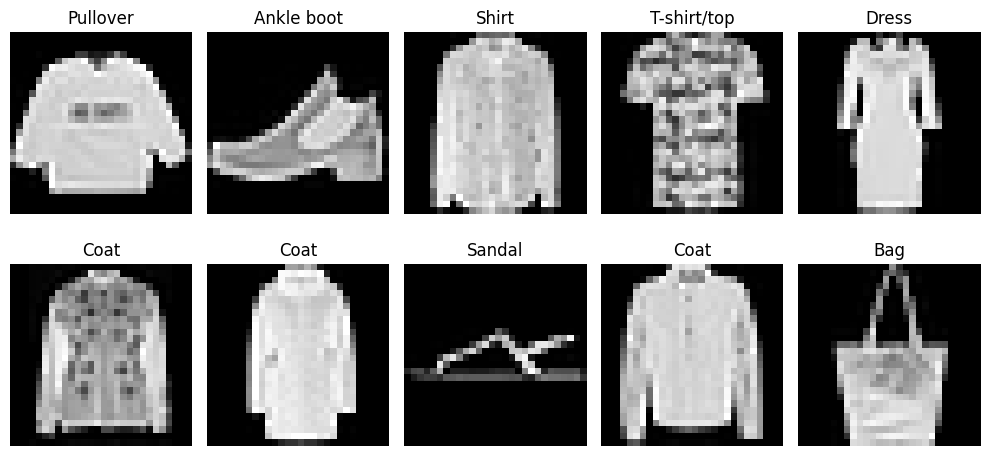

In [10]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(10, activation="softmax")
])

print("CNN model created successfully!")

CNN model created successfully!


In [14]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

print("CNN training completed!")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.7550 - loss: 0.6839 - val_accuracy: 0.8398 - val_loss: 0.4386
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.8399 - loss: 0.4481 - val_accuracy: 0.8695 - val_loss: 0.3633
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.8608 - loss: 0.3880 - val_accuracy: 0.8835 - val_loss: 0.3235
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.8742 - loss: 0.3554 - val_accuracy: 0.8940 - val_loss: 0.2991
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.8820 - loss: 0.3309 - val_accuracy: 0.8925 - val_loss: 0.2999
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.8892 - loss: 0.3108 - val_accuracy: 0.9002 - val_loss: 0.2740
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.8946 - loss: 0.2936 - val_accuracy: 0.9045 - val_loss: 0.2659
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.8998 - loss: 0.2776 - 

In [17]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.2410
Test Accuracy: 90.84%


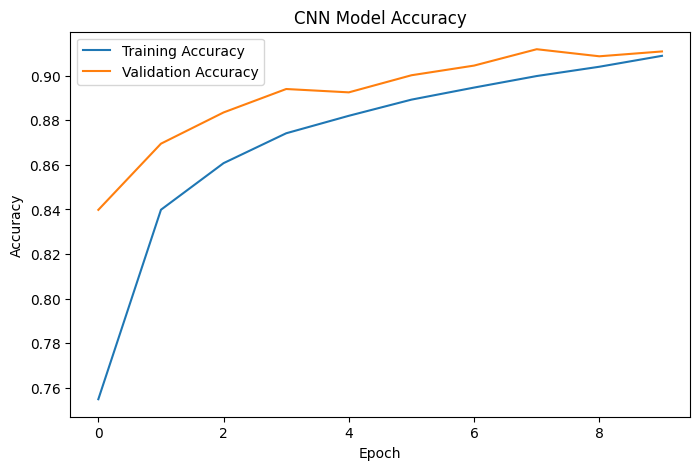

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("CNN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

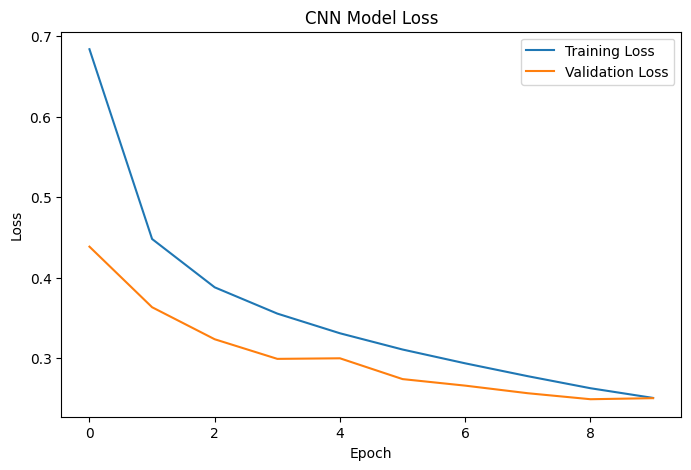

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("CNN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [20]:
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Predictions completed successfully!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Predictions completed successfully!


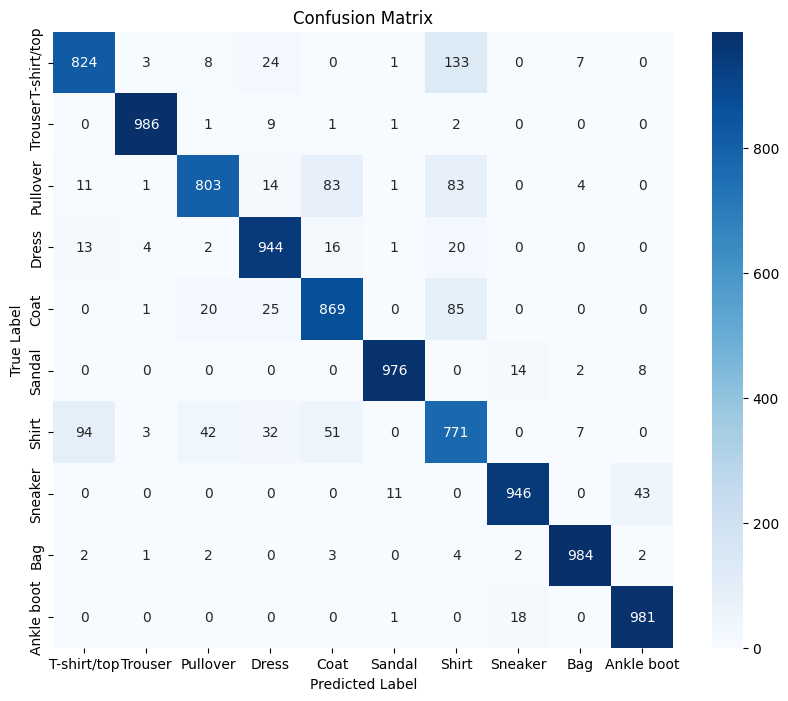

In [21]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [22]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.82      0.85      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.91      0.80      0.86      1000
       Dress       0.90      0.94      0.92      1000
        Coat       0.85      0.87      0.86      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.70      0.77      0.73      1000
     Sneaker       0.97      0.95      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.95      0.98      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



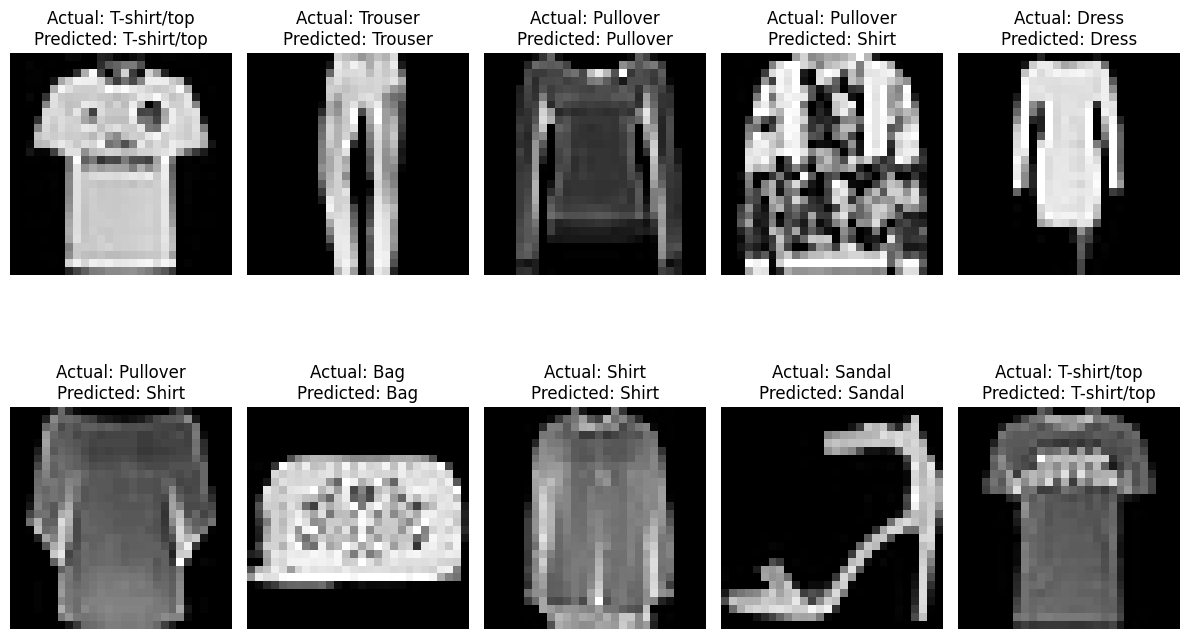

In [23]:
plt.figure(figsize=(12, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")

    predicted_label = class_names[y_pred[i]]
    actual_label = class_names[y_true[i]]

    plt.title(
        f"Actual: {actual_label}\nPredicted: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
print("=" * 55)
print("CNN FASHION-MNIST CLASSIFICATION PROJECT COMPLETED")
print("=" * 55)

print(f"\nFinal Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

print("\nDataset: Fashion-MNIST")
print("Algorithm: Convolutional Neural Network (CNN)")
print("Classes: 10")

print("\nProject completed successfully! 🎉")

CNN FASHION-MNIST CLASSIFICATION PROJECT COMPLETED

Final Test Accuracy: 90.84%
Final Test Loss: 0.2410

Dataset: Fashion-MNIST
Algorithm: Convolutional Neural Network (CNN)
Classes: 10

Project completed successfully! 🎉
